In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn import metrics
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('boxoffice.csv')

In [4]:
df.head(5)

,title,domestic_revenue,world_revenue,distributor,opening_revenue,opening_theaters,budget,MPAA,genres,release_days
0,The Avengers,6026491,1274885664,Warner Bros.,163620146,253,174687337,R,Animation,16
1,Titanic,169411543,1132871091,Disney,85549990,122,103948486,G,Action,103
2,Jurassic Park,107836098,583329845,Sony,55681429,3826,122104991,NC-17,Horror,89
3,Avatar,51433697,1225323391,Disney,109775324,3868,46431596,G,Horror,85
4,The Lion King,142791649,604140729,Warner Bros.,59476800,2934,203513696,R,Comedy,158


In [5]:
df.shape

(2694, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2694 entries, 0 to 2693
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   title             2694 non-null   object
 1   domestic_revenue  2694 non-null   int64 
 2   world_revenue     2694 non-null   int64 
 3   distributor       2694 non-null   object
 4   opening_revenue   2694 non-null   int64 
 5   opening_theaters  2694 non-null   int64 
 6   budget            2694 non-null   int64 
 7   MPAA              2694 non-null   object
 8   genres            2694 non-null   object
 9   release_days      2694 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 210.6+ KB


In [7]:
df.describe()

,domestic_revenue,world_revenue,opening_revenue,opening_theaters,budget,release_days
count,2.694000e+03,2.694000e+03,2.694000e+03,2694.000000,2.694000e+03,2694.000000
mean,1.508539e+08,7.719177e+08,9.971321e+07,2263.039347,1.537996e+08,90.897550
std,8.579997e+07,4.284414e+08,5.721762e+07,1298.559140,8.557624e+07,50.894041
min,8.277650e+05,3.261301e+06,1.385690e+05,10.000000,5.197977e+06,1.000000
25%,7.673272e+07,3.991135e+08,5.033848e+07,1161.000000,7.861876e+07,47.000000
50%,1.525725e+08,7.665551e+08,9.981418e+07,2271.500000,1.562567e+08,91.000000
75%,2.247314e+08,1.143920e+09,1.489805e+08,3392.250000,2.274832e+08,135.000000
max,2.998107e+08,1.499310e+09,1.999336e+08,4499.000000,2.998597e+08,179.000000


In [8]:
df.drop(columns=["world_revenue","opening_revenue",],axis=1,inplace=True)
df.shape

(2694, 8)

In [9]:
df.sample(30)

,title,domestic_revenue,distributor,opening_theaters,budget,MPAA,genres,release_days
2576,Avatar,127149771,Disney,2188,165512947,R,Action,62
1312,Toy Story,281960029,Paramount,59,36414181,PG,Drama,71
296,Captain America,73623648,Universal,4460,218093756,PG,Horror,87
1229,Guardians of the Galaxy,169082373,Disney,102,117058578,R,Drama,96
585,Interstellar,7266202,Universal,4294,156713215,PG-13,Animation,97
1621,Harry Potter,103911640,Warner Bros.,3091,145884170,R,Horror,148
2296,Jurassic Park,270407018,Sony,2792,151545899,PG,Comedy,115
2356,The Avengers,95479258,Sony,138,80328284,NC-17,Horror,17
1478,Coco,246111224,Disney,1797,72463425,R,Action,134
192,Frozen,160318338,Paramount,3481,285773309,G,Horror,1


In [10]:
df.drop('budget',axis=1,inplace=True)

In [11]:
df.shape

(2694, 7)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2694 entries, 0 to 2693
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   title             2694 non-null   object
 1   domestic_revenue  2694 non-null   int64 
 2   distributor       2694 non-null   object
 3   opening_theaters  2694 non-null   int64 
 4   MPAA              2694 non-null   object
 5   genres            2694 non-null   object
 6   release_days      2694 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 147.5+ KB


In [13]:
for col in ['domestic_revenue','opening_theaters','release_days']:
    df[col]=(
        df[col].astype(str)
        .str.replace('$',' ')
        .str.replace(',',' ',regex=False)
                    )
df[col]=pd.to_numeric(df[col],errors='coerce')

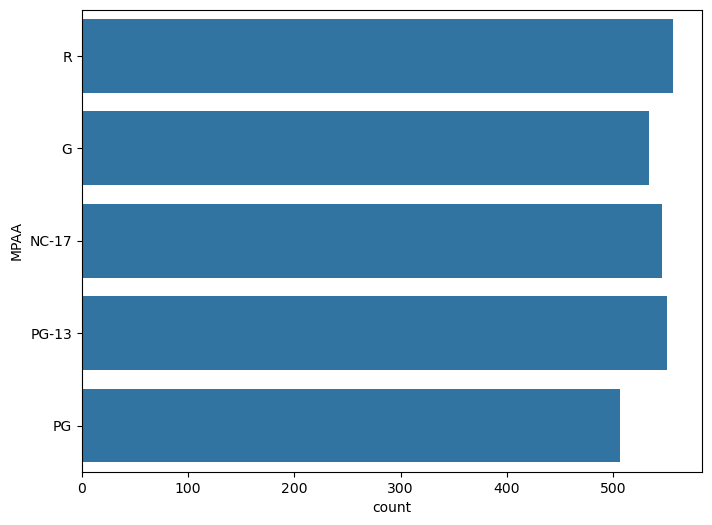

In [14]:
plt.figure(figsize=(8,6))
sns.countplot(df['MPAA'])
plt.show()

In [15]:
df['domestic_revenue'] = pd.to_numeric(df['domestic_revenue'].astype(str).str.replace(r'[$,]', '', regex=True), errors='coerce')


In [16]:
df.groupby('MPAA')['domestic_revenue'].mean()

MPAA
G        1.465288e+08
NC-17    1.507193e+08
PG       1.529123e+08
PG-13    1.477556e+08
R        1.563334e+08
Name: domestic_revenue, dtype: float64

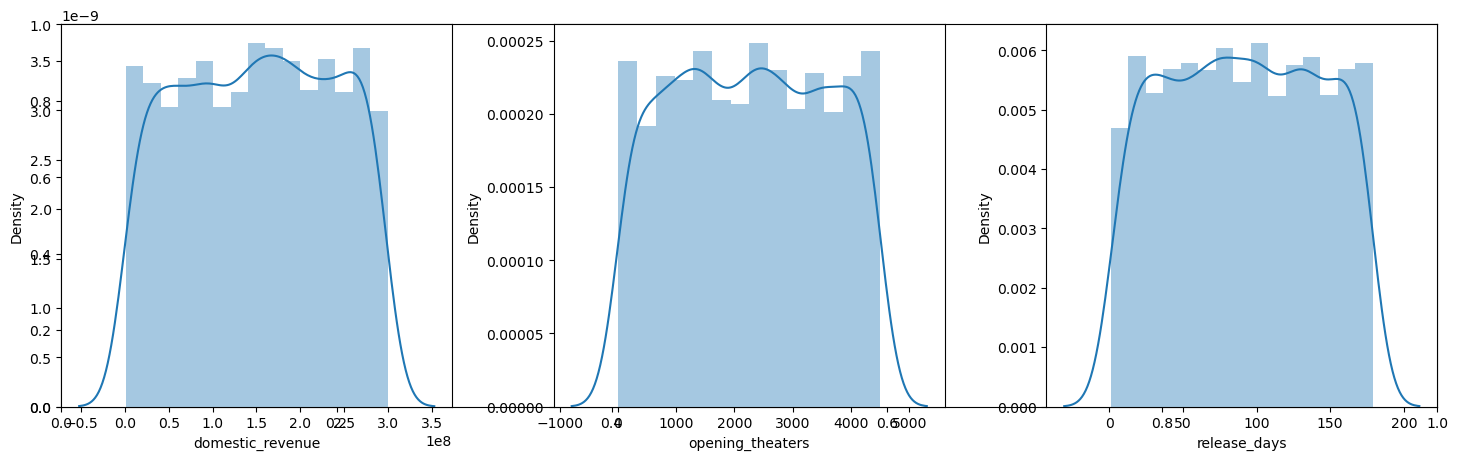

In [30]:
plt.subplots(figsize=(15,5))
features=['domestic_revenue','opening_theaters','release_days']
for i,col in enumerate(features):
    plt.subplot(1,3, i+1)
    sns.distplot(df[col])
plt.tight_layout()
plt.show()

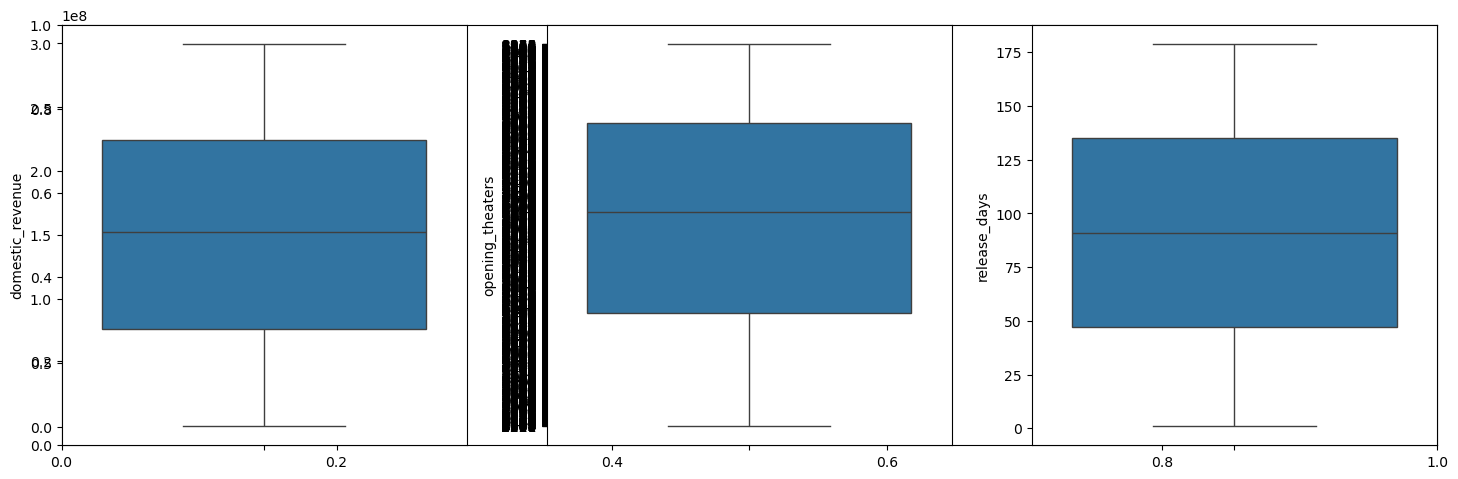

In [31]:
plt.subplots(figsize=(15,5))
for i ,col in enumerate(features):
    plt.subplot(1,3, i+1)
    sns.boxplot(df[col])
plt.tight_layout()
plt.show()
    

In [35]:
df[features]=np.log10(df[features].astype(float).clip(lower=1))

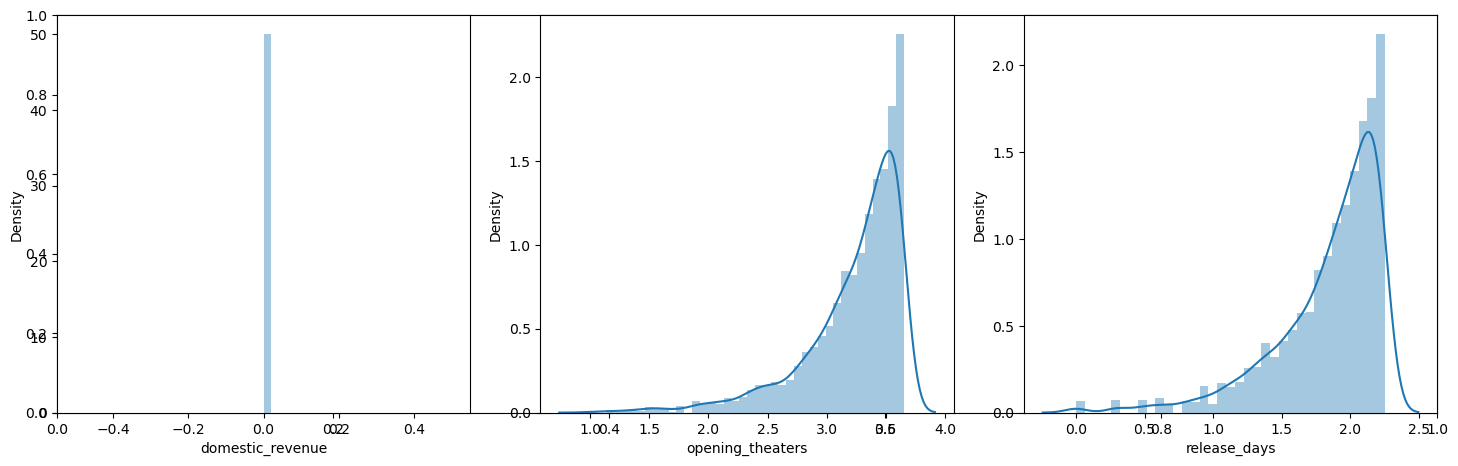

In [36]:
plt.subplots(figsize=(15,5))
features=['domestic_revenue','opening_theaters','release_days']
for i,col in enumerate(features):
    plt.subplot(1,3, i+1)
    sns.distplot(df[col])
plt.tight_layout()
plt.show()

In [37]:
vectorizer = CountVectorizer() 
vectorizer.fit(df['genres']) 
features = vectorizer.transform(df['genres']).toarray() 

genres = vectorizer.get_feature_names_out() 
for i, name in enumerate(genres): 
	df[name] = features[:, i] 

df.drop('genres', axis=1, inplace=True)

In [42]:
removed = 0

if 'action' in df.columns and 'western' in df.columns:
    for col in df.loc[:, 'action':'western'].columns: 
        
        if (df[col] == 0).mean() > 0.95: 
            removed += 1
            df.drop(col, axis=1, inplace=True) 

print(removed) 
print(df.shape)

0
(2694, 12)


In [43]:
for col in ['distributor','MPAA']:
    le=LabelEncoder()
    df[col]= le.fit_transform(df[col])

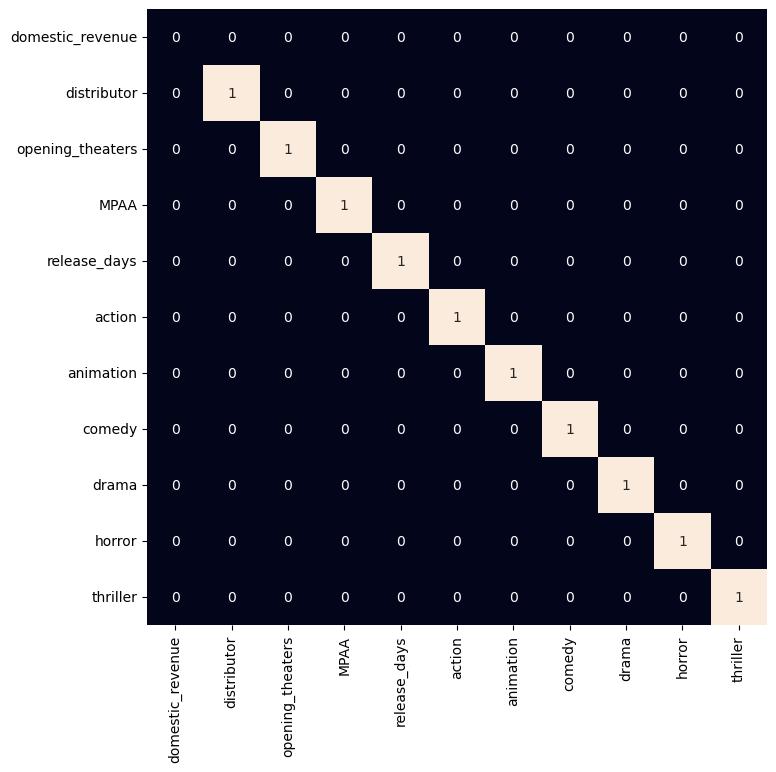

In [53]:
plt.figure(figsize=(8, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr() > 0.8, 
            annot=True, 
            cbar=False) 
plt.show()

In [66]:
X= df.drop(['title', 'domestic_revenue'], axis=1) 
Y= df['domestic_revenue'].values 

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, 
									test_size=0.1, 
									random_state=22) 
X_train.shape, X_test.shape

((2424, 10), (270, 10))

In [67]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train_scaled, Y_train)


,objective,'reg:squarederror'
,base_score,0.5
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,1
,colsample_bynode,1
,colsample_bytree,1
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,gamma,0


In [71]:
from sklearn.metrics import mean_squared_error, r2_score

train_pred = model.predict(X_train_scaled)
test_pred  = model.predict(X_test_scaled)

print("Train RMSE :", mean_squared_error(Y_train, train_pred))
print("Test  RMSE :", mean_squared_error(Y_test, test_pred))
print("Train R2   :", r2_score(Y_train, train_pred))
print("Test  R2   :", r2_score(Y_test, test_pred))


Train RMSE : 1.78000539427775e-10
Test  RMSE : 1.7800053942777497e-10
Train R2   : 0.0
Test  R2   : 0.0
